<a href="https://colab.research.google.com/github/Najla-Nuricia/PCVK26_19_Najla/blob/main/Praktikum4_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Najla Nuricia Laudy'
NIM = '244107020091'

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Najla Nuricia Laudy
NIM : 244107020091 | N = 91
bins   : 64
clip   : 1.5
tile   : 5
L      : 4
WAKTU : 2026-09-22 18:20:07 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : fe842b72ad3e652d


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import math
import os
import glob

In [7]:
CONTOH = '/content/drive/MyDrive/coolyeah /PCVK'
BASE = '/content/drive/MyDrive/coolyeah /PCVK' + NIM

<BarContainer object of 256 artists>

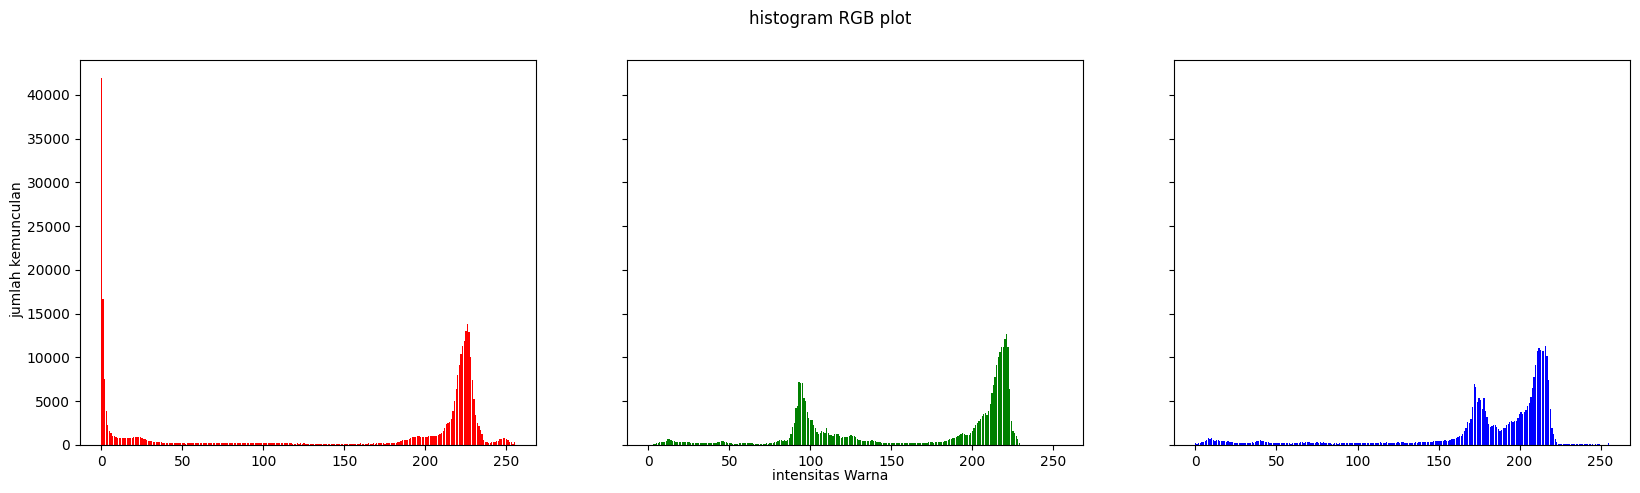

In [ ]:
img = cv.imread(CONTOH + '/Ktm1b.jpeg')
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]* 256
green = [0]* 256
blue = [0]* 256


for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] +=1
    green[img[y][x][1]] +=1
    blue[img[y][x][2]] +=1

names = np.arange(256)
fig, axs = plt.subplots(1,3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('histogram RGB plot')
fig.text(0.09,0.5,'jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04,'intensitas Warna', ha='center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')

Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [ ]:
np_red, _ = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
np_green, _ = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
np_blue, _ = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

cv_red = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
cv_green = cv.calcHist([img], [1], None, [256], [0, 256]).flatten()
cv_blue = cv.calcHist([img], [2], None, [256], [0, 256]).flatten()


print("RED")
print("Manual vs NumPy :", np.max(np.abs(np.array(red) - np_red)))
print("Manual vs OpenCV:", np.max(np.abs(np.array(red) - cv_red)))
print("NumPy vs OpenCV :", np.max(np.abs(np_red - cv_red)))

print("\nGREEN")
print("Manual vs NumPy :", np.max(np.abs(np.array(green) - np_green)))
print("Manual vs OpenCV:", np.max(np.abs(np.array(green) - cv_green)))
print("NumPy vs OpenCV :", np.max(np.abs(np_green - cv_green)))

print("\nBLUE")
print("Manual vs NumPy :", np.max(np.abs(np.array(blue) - np_blue)))
print("Manual vs OpenCV:", np.max(np.abs(np.array(blue) - cv_blue)))
print("NumPy vs OpenCV :", np.max(np.abs(np_blue - cv_blue)))

RED
Manual vs NumPy : 0
Manual vs OpenCV: 0.0
NumPy vs OpenCV : 0.0

GREEN
Manual vs NumPy : 0
Manual vs OpenCV: 0.0
NumPy vs OpenCV : 0.0

BLUE
Manual vs NumPy : 0
Manual vs OpenCV: 0.0
NumPy vs OpenCV : 0.0


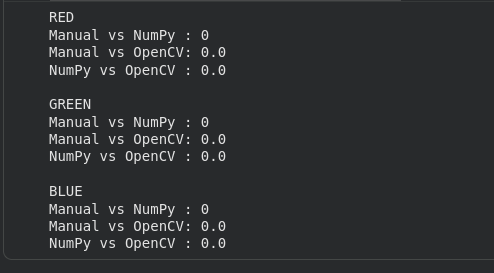

Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

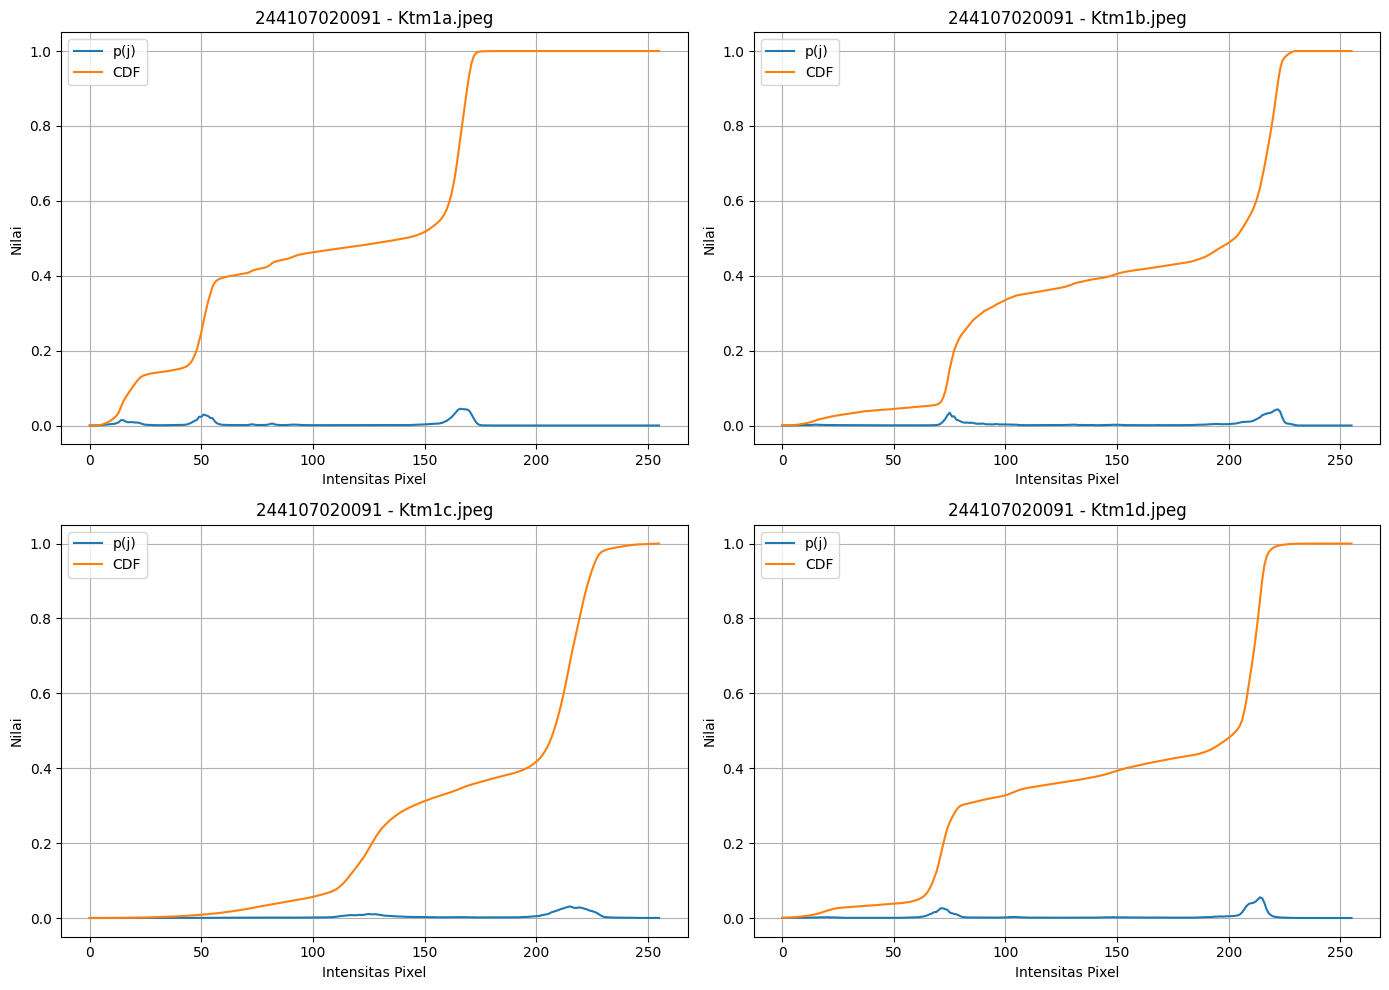

In [ ]:
files = ['Ktm1a.jpeg', 'Ktm1b.jpeg', 'Ktm1c.jpeg', 'Ktm1d.jpeg']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for ax, file in zip(axs.ravel(), files):
    img = cv.imread(CONTOH + '/' + file, cv.IMREAD_GRAYSCALE)

    hist, _ = np.histogram(img, bins=256, range=(0, 256))
    p = hist / img.size
    cdf = np.cumsum(p)

    ax.plot(np.arange(256), p, label='p(j)')
    ax.plot(np.arange(256), cdf, label='CDF')

    ax.set_title(NIM + ' - ' + file)
    ax.set_xlabel('Intensitas Pixel')
    ax.set_ylabel('Nilai')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

pada citra palign gelap yaitu ktm 1a menandakan pixel yang gelap 0 - 100 lebih banyak dibanding image paling terang ktm 1c di mana 0 - 100 yang paling sedikit dari semua gambar

Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

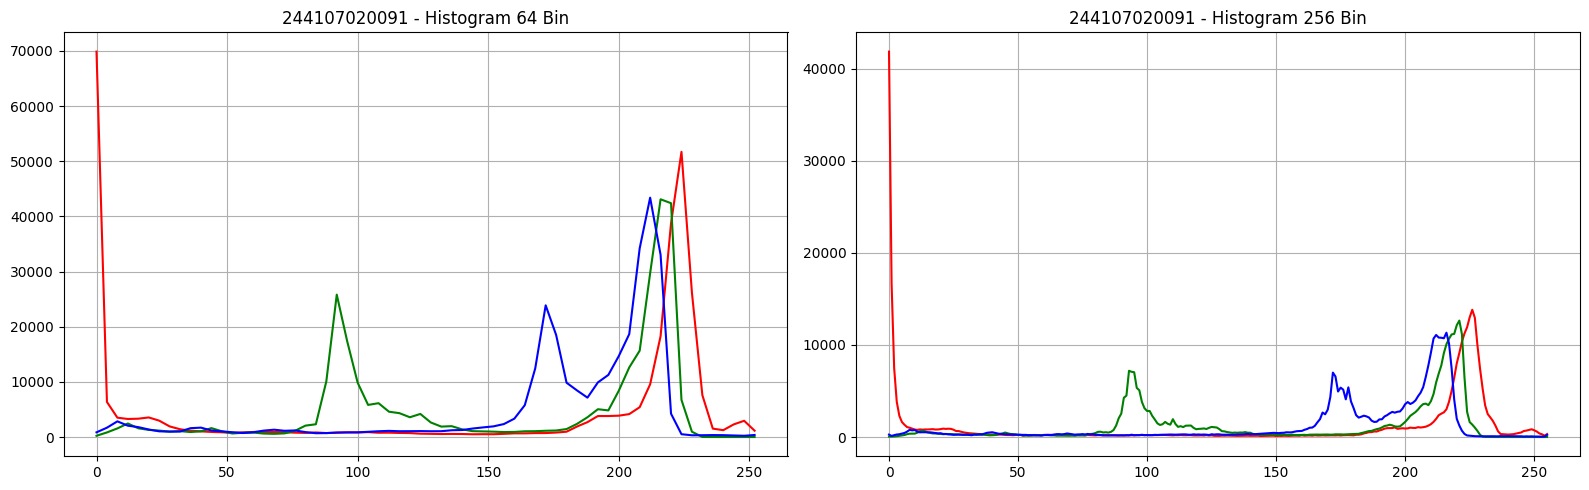

In [ ]:
img = cv.imread(CONTOH + '/Ktm1b.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# Histogram dengan PARAM['bins']
for i, color in enumerate(['red', 'green', 'blue']):
    hist, edges = np.histogram(img[:, :, i], bins=PARAM['bins'], range=(0, 256))
    axs[0].plot(edges[:-1], hist, color=color, label=color.capitalize())

axs[0].set_title(NIM + f" - Histogram {PARAM['bins']} Bin")
axs[0].grid()

# Histogram dengan 256 bin
for i, color in enumerate(['red', 'green', 'blue']):
    hist, edges = np.histogram(img[:, :, i], bins=256, range=(0, 256))
    axs[1].plot(edges[:-1], hist, color=color, label=color.capitalize())

axs[1].set_title(NIM + ' - Histogram 256 Bin')
axs[1].grid()

plt.tight_layout()
plt.show()

Pada histogram 64 bin, Puncak histogram terlihat lebih tinggi karena jumlah piksel dari beberapa intensitas dijumlahkan dalam satu kelompok.

Pada histogram 256 bin, terlihat lebih rinci karena pixel dijumlahkan dengan nilai sesamanya tidak dikelompok2 kan

In [ ]:
def equalize_manual(gray):
    hist = np.zeros(256, dtype=np.int64)

    for y in range(gray.shape[0]):
        for x in range(gray.shape[1]):
            hist[gray[y, x]] += 1

    cdf = np.cumsum(hist)

    cdf_min = cdf[cdf > 0][0]

    mapping = np.round(
        (cdf - cdf_min) /
        (gray.size - cdf_min) * 255
    )

    mapping = np.clip(mapping, 0, 255).astype(np.uint8)

    return mapping[gray]

In [ ]:
img = cv.imread(
    CONTOH + '/lena_lc.jpg'
)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

r, g, b = cv.split(img_rgb)

r_eq = equalize_manual(r)
g_eq = equalize_manual(g)
b_eq = equalize_manual(b)

hasil_manual = cv.merge([r_eq, g_eq, b_eq])

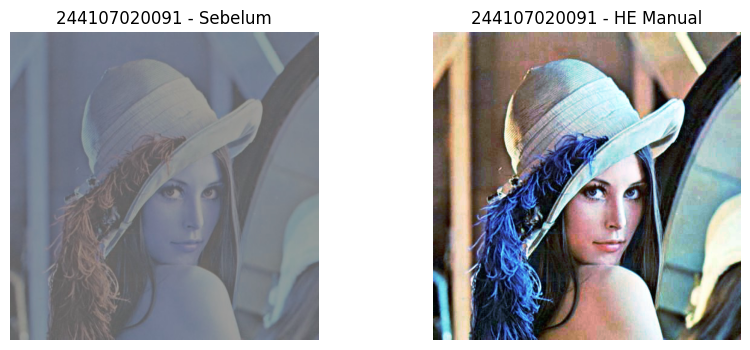

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Sebelum')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hasil_manual, cmap='gray')
plt.title(NIM + ' - HE Manual')
plt.axis('off')

plt.show()

In [ ]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt

berkas = CONTOH + '/Ktm1d.jpeg' # tahap 1; tahap 2 ganti: BASE + '/KTM1d.jpg'
bgr = cv.imread(berkas)
# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
  kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

In [ ]:
#cara 2: hanya kanal terang yang diekualisasi
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# varian setara pada ruang warna lain
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

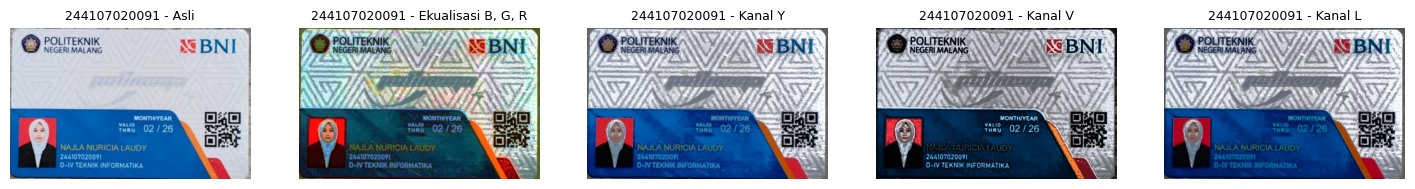

In [ ]:
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
  plt.subplot(1, 5, i)
  plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
  plt.title(NIM + ' - ' + t, fontsize=9)
  plt.axis('off')
plt.show()

In [ ]:
def geser_hue(asli, hasil):
  h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  d = np.abs(h1 - h2)
  d = np.minimum(d, 180 - d) # Hue melingkar 0-179
  return d.mean()


print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
  print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            156.0
Ekualisasi B, G, R                55.86            125.9
Kanal Y                            2.15            132.3
Kanal V                            2.13            111.6
Kanal L                            5.12            123.8


In [ ]:
import pandas as pd

data = [
    ['Citra asli', 0.00, 156.0, 'aman'],
    ['Ekualisasi kanal B, G, R', 55.86, 125.9, 'warn ajadi gelap dan agak kebiruan'],
    ['Kanal Y (YCrCb)', 2.15, 132.3, 'cerah dibandig yang lain'],
    ['Kanal V (HSV)', 2.13, 111.6, 'lebih gelap dan warna merah nya agak pudar'],
    ['Kanal L (LAB)', 5.12, 123.8, 'lebih gelap dari kanal Y']
]

df = pd.DataFrame(
    data,
    columns=[
        'Cara Ekualisasi',
        'Rata-rata Pergeseran Hue (derajat)',
        'Rerata Kecerahan Sesudah',
        'Catatan Pengamatan'
    ]
)

display(df)

,Cara Ekualisasi,Rata-rata Pergeseran Hue (derajat),Rerata Kecerahan Sesudah,Catatan Pengamatan
0,Citra asli,0.00,156.0,aman
1,"Ekualisasi kanal B, G, R",55.86,125.9,warn ajadi gelap dan agak kebiruan
2,Kanal Y (YCrCb),2.15,132.3,cerah dibandig yang lain
3,Kanal V (HSV),2.13,111.6,lebih gelap dan warna merah nya agak pudar
4,Kanal L (LAB),5.12,123.8,lebih gelap dari kanal Y


1. ekualisasi BGR yaitu 55
2. Karena setelah kanal Y, V, atau L diubah, gambar harus dikembalikan ke BGR. Saat proses itu ada pembulatan dan clipping nilai pixel, jadi warna bisa berubah sedikit. Akibatnya nilai Hue tidak benar-benar sama dengan citra asli
3. Kanal Y karena pergerseran hue relatif kecil dan jug akecerahan 132 yang mana tertinggi jika tida melibatkan citra asli

In [ ]:
# CLAHE pada kanal Y
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

y_clahe = clahe.apply(y)

he_y_clahe = cv.cvtColor(
    cv.merge([y_clahe, cr, cb]),
    cv.COLOR_YCrCb2BGR
)

# Hitung pergeseran Hue
hue_clahe = geser_hue(bgr, he_y_clahe) * 2

# Hitung rerata kecerahan
terang_clahe = cv.cvtColor(
    he_y_clahe,
    cv.COLOR_BGR2GRAY
).mean()

print('Equalization Y biasa')
print('Pergeseran Hue :', round(geser_hue(bgr, he_y) * 2, 2))
print('Rerata terang  :', round(cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean(), 1))

print('\nCLAHE Y')
print('Pergeseran Hue :', round(hue_clahe, 2))
print('Rerata terang  :', round(terang_clahe, 1))

Equalization Y biasa
Pergeseran Hue : 2.15
Rerata terang  : 132.3

CLAHE Y
Pergeseran Hue : 0.12
Rerata terang  : 157.2


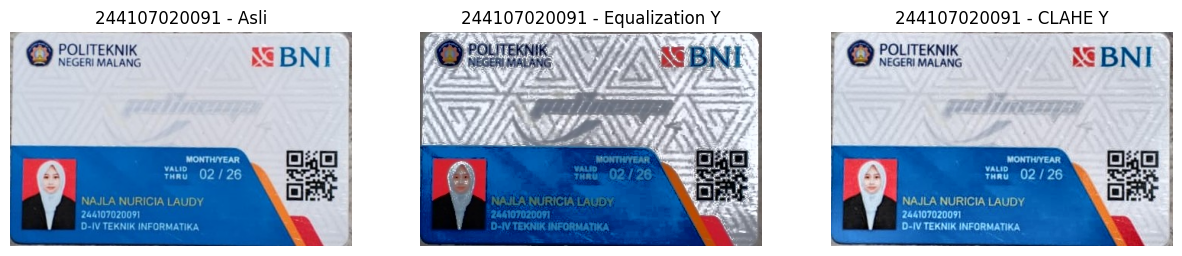

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization Y')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(he_y_clahe, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - CLAHE Y')
plt.axis('off')

plt.show()

Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.

In [ ]:
img = cv.imread(
    CONTOH + '/Ktm1a.jpeg',
    cv.IMREAD_GRAYSCALE
)

hasil_manual = equalize_manual(img)
hasil_cv = cv.equalizeHist(img)

ampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout

/tmp/ipykernel_742/2243677358.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0,256])
/tmp/ipykernel_742/2243677358.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(hasil_manual.ravel(), 256, [0,256])
/tmp/ipykernel_742/2243677358.py:33: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(hasil_cv.ravel(), 256, [0,256])


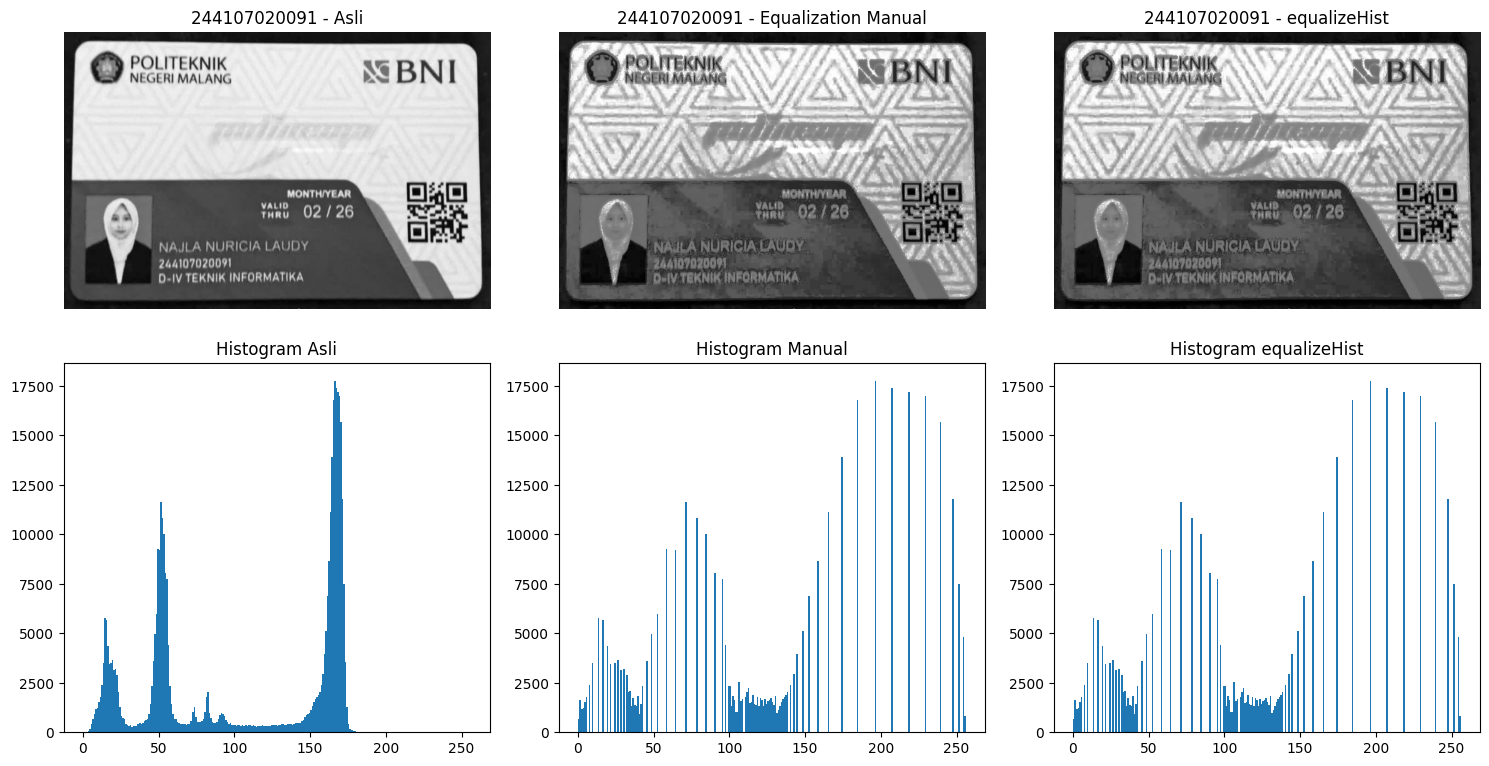

In [ ]:
plt.figure(figsize=(15, 8))

# Citra asli
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Asli')
plt.axis('off')

# Manual
plt.subplot(2, 3, 2)
plt.imshow(hasil_manual, cmap='gray')
plt.title(NIM + ' - Equalization Manual')
plt.axis('off')

# OpenCV
plt.subplot(2, 3, 3)
plt.imshow(hasil_cv, cmap='gray')
plt.title(NIM + ' - equalizeHist')
plt.axis('off')

# Histogram asli
plt.subplot(2, 3, 4)
plt.hist(img.ravel(), 256, [0,256])
plt.title('Histogram Asli')

# Histogram manual
plt.subplot(2, 3, 5)
plt.hist(hasil_manual.ravel(), 256, [0,256])
plt.title('Histogram Manual')

# Histogram OpenCV
plt.subplot(2, 3, 6)
plt.hist(hasil_cv.ravel(), 256, [0,256])
plt.title('Histogram equalizeHist')

plt.tight_layout()
plt.show()

Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.

In [ ]:
def psnr(img1, img2):
    mse = np.mean(
        (img1.astype(np.float32) - img2.astype(np.float32)) ** 2
    )

    if mse == 0:
        return float('inf')

    return 10 * np.log10((255 ** 2) / mse)

print("PSNR Manual :", psnr(img, hasil_manual))
print("PSNR OpenCV :", psnr(img, hasil_cv))

PSNR Manual : 17.302013
PSNR OpenCV : 17.302013


Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

In [ ]:
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

hasil_clahe = clahe.apply(img)

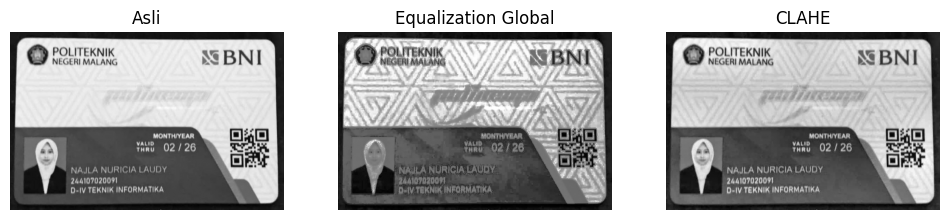

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Asli')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(hasil_cv, cmap='gray')
plt.title('Equalization Global')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil_clahe, cmap='gray')
plt.title('CLAHE')
plt.axis('off')

plt.show()

Clahe lebih terbaca

In [ ]:
clip_values = [
    max(0.5, PARAM['clip'] - 1.0),
    PARAM['clip'],
    PARAM['clip'] + 1.0,
    PARAM['clip'] + 2.0
]

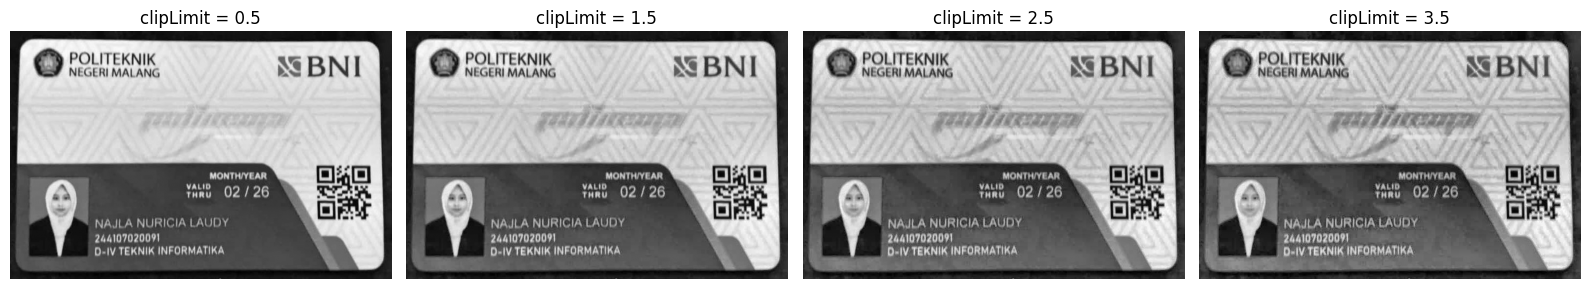

In [ ]:
plt.figure(figsize=(16,4))

for i, clip in enumerate(clip_values, 1):

    clahe_test = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )

    hasil = clahe_test.apply(img)

    plt.subplot(1,4,i)
    plt.imshow(hasil, cmap='gray')
    plt.title(f'clipLimit = {clip}')
    plt.axis('off')

plt.tight_layout()
plt.show()

clip limit 0.5 yang lebih jelas tulisannya.

noise mulai menonjol di 1.5

Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].
Gambar berikut adalah keluaran yang harus Anda peroleh pada tahap 1 dengan citra contoh. Bila
keluaran Anda berbeda, perbaiki kode lebih dulu sebelum melanjutkan ke tahap 2 dengan citra KTM
Anda.

In [16]:
def floyd_steinberg(img, L):
    hasil = img.astype(np.float32).copy()

    step = 255.0 / (L - 1)

    h, w, c = hasil.shape

    for y in range(h):
        for x in range(w):
            for ch in range(c):
                lama = hasil[y, x, ch]

                baru = np.round(lama / step) * step

                hasil[y, x, ch] = baru

                error = lama - baru

                if x + 1 < w:
                    hasil[y, x + 1, ch] += error * 7 / 16

                if x > 0 and y + 1 < h:
                    hasil[y + 1, x - 1, ch] += error * 3 / 16

                if y + 1 < h:
                    hasil[y + 1, x, ch] += error * 5 / 16

                if x + 1 < w and y + 1 < h:
                    hasil[y + 1, x + 1, ch] += error * 1 / 16

    return np.clip(hasil, 0, 255).astype(np.uint8)

In [26]:
img = cv.imread(
    CONTOH + '/Ktm1b.jpeg',
)

hasil = floyd_steinberg(
    img,
    L=PARAM['L']
)

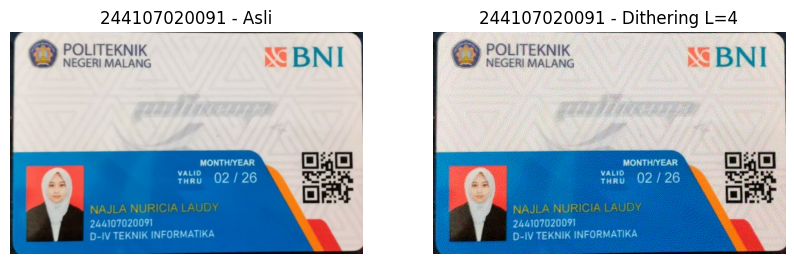

In [27]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
plt.title(NIM + f" - Dithering L={PARAM['L']}")
plt.axis('off')

plt.show()

In [31]:
def floyd_steinberg_gray(img, L):
    hasil = img.astype(np.float32).copy()

    step = 255.0 / (L - 1)
    h, w = hasil.shape

    for y in range(h):
        for x in range(w):
            lama = hasil[y, x]
            baru = np.round(lama / step) * step

            hasil[y, x] = baru
            error = lama - baru

            if x + 1 < w:
                hasil[y, x + 1] += error * 7 / 16

            if x > 0 and y + 1 < h:
                hasil[y + 1, x - 1] += error * 3 / 16

            if y + 1 < h:
                hasil[y + 1, x] += error * 5 / 16

            if x + 1 < w and y + 1 < h:
                hasil[y + 1, x + 1] += error * 1 / 16

    return np.clip(hasil, 0, 255).astype(np.uint8)

In [32]:
img = cv.imread(
    CONTOH + '/Ktm1a.jpeg',
    cv.IMREAD_GRAYSCALE
)

dither_langsung = floyd_steinberg_gray(
    img,
    PARAM['L']
)

hasil_he = cv.equalizeHist(img)

he_dither = floyd_steinberg_gray(
    hasil_he,
    PARAM['L']
)

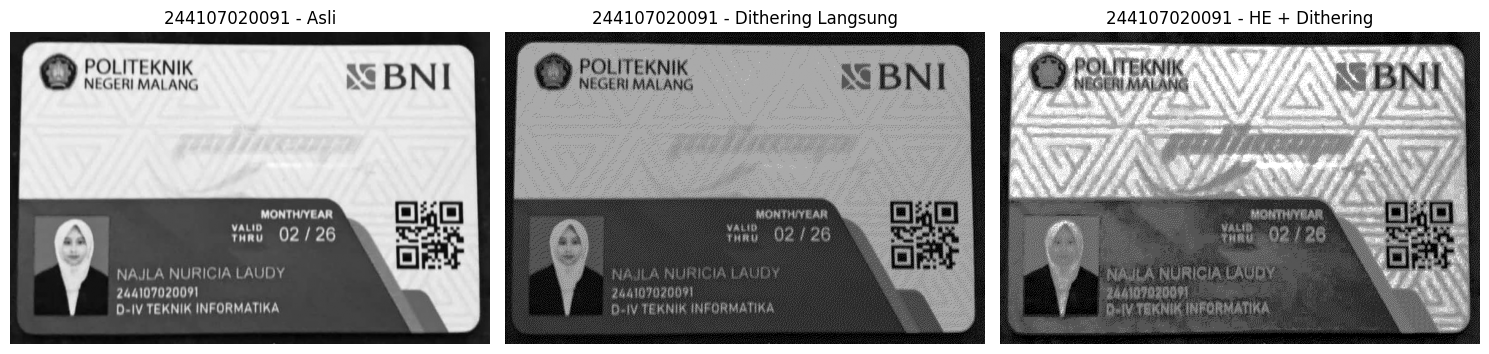

In [33]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(dither_langsung, cmap='gray')
plt.title(NIM + ' - Dithering Langsung')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(he_dither, cmap='gray')
plt.title(NIM + ' - HE + Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

yang lebih terbaca adalah dithering langsung lalu HE + dithering